In [32]:
import numpy as np
import os
import json
import pandas as pd
import matplotlib.pyplot as plt

In [33]:
def load_agent(run_folder):
    """Example of how to load the agent back"""
    
    # Load Tables
    data = np.load(os.path.join(run_folder, 'model.npz'))
    q_table = data['Q_table']
    n_table = data['N_table']
    
    # Load Config (to reconstruct the agent structure)
    with open(os.path.join(run_folder, 'config.json'), 'r') as f:
        config = json.load(f)
        
    print(f"Loaded agent from {run_folder}")
    return q_table, n_table, config

def load_metrics(run_folder):
    """Load the CSV for plotting"""
    return pd.read_csv(os.path.join(run_folder, 'training_log.csv'))

In [34]:
run_path = '../results/20260129_013016_Ep200_Gamma0.99_Zscore'
q_table, n_table, config = load_agent(run_path)
metrics = load_metrics(run_path)


Loaded agent from ../results/20260129_013016_Ep200_Gamma0.99_Zscore


In [35]:
metrics

,episode,epsilon,lr,raw_reward,q_reward,train_rollout,val_rollout,q_delta,q_mean,n_table_pct_non_zero,n_table_min,n_table_max,n_table_mean,n_table_median
0,0,1.000000,1.000000,-36812.009933,-51221.390572,-42606.696144,-49090.256757,59.727057,375.746077,97.6,1,81,17.901639,13.0
1,1,0.994722,0.707107,-18821.155008,-29388.843165,-207773.779529,-131428.115346,59.560090,961.399216,100.0,1,122,34.944000,25.0
2,2,0.989444,0.577350,-17999.188318,-27511.229037,-43737.289207,-24134.397207,62.050898,1808.816863,100.0,1,191,52.416000,38.0
3,3,0.984167,0.500000,-31382.829398,-45408.673565,-50012.415561,-39941.558624,35.816355,2225.524726,100.0,2,236,69.888000,50.0
4,4,0.978889,0.447214,-18850.244134,-28332.456862,-9202.585692,-13796.513449,21.126816,2404.333952,100.0,4,302,87.360000,60.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
195,195,0.050000,0.071429,14433.905213,8835.262968,57948.310640,-9027.459557,0.995354,478.477739,100.0,113,52870,3424.512000,2299.0
196,196,0.050000,0.071247,30108.532955,20521.975689,124811.701230,35357.177720,1.284528,477.709986,100.0,114,53135,3441.984000,2302.0
197,197,0.050000,0.071067,26688.787580,19918.083360,132427.133559,43622.601059,1.042617,477.603326,100.0,114,53947,3459.456000,2302.0
198,198,0.050000,0.070888,22967.284530,19660.886807,132399.305264,43429.132867,0.987168,479.251353,100.0,114,54631,3476.928000,2302.5


In [37]:
metrics.columns

Index(['episode', 'epsilon', 'lr', 'raw_reward', 'q_reward', 'train_rollout',
       'val_rollout', 'q_delta', 'q_mean', 'n_table_pct_non_zero',
       'n_table_min', 'n_table_max', 'n_table_mean', 'n_table_median'],
      dtype='object')

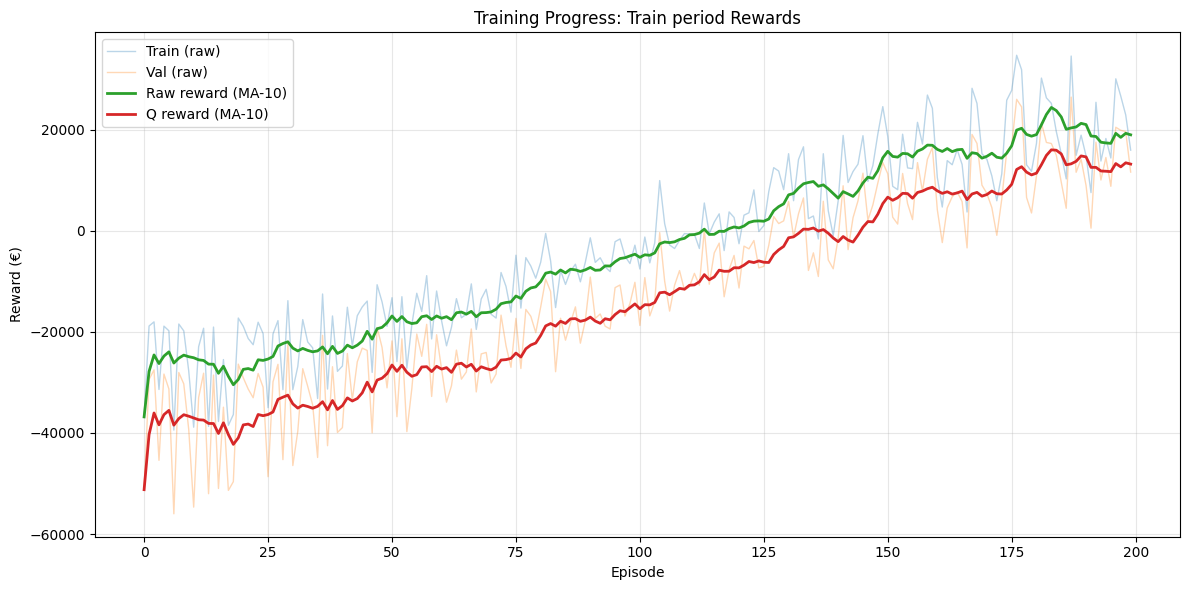

In [43]:
plt.figure(figsize=(12, 6))

# Plot raw data (lighter, thinner)
plt.plot(metrics.episode, metrics.raw_reward, alpha=0.3, linewidth=1, label='Train (raw)')
plt.plot(metrics.episode, metrics.q_reward, alpha=0.3, linewidth=1, label='Val (raw)')

# Plot moving averages (darker, thicker)
window = 10
train_ma = metrics.raw_reward.rolling(window=window, min_periods=1).mean()
val_ma = metrics.q_reward.rolling(window=window, min_periods=1).mean()

plt.plot(metrics.episode, train_ma, linewidth=2, label=f'Raw reward (MA-{window})')
plt.plot(metrics.episode, val_ma, linewidth=2, label=f'Q reward (MA-{window})')

plt.xlabel('Episode')
plt.ylabel('Reward (€)')
plt.title('Training Progress: Train period Rewards')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

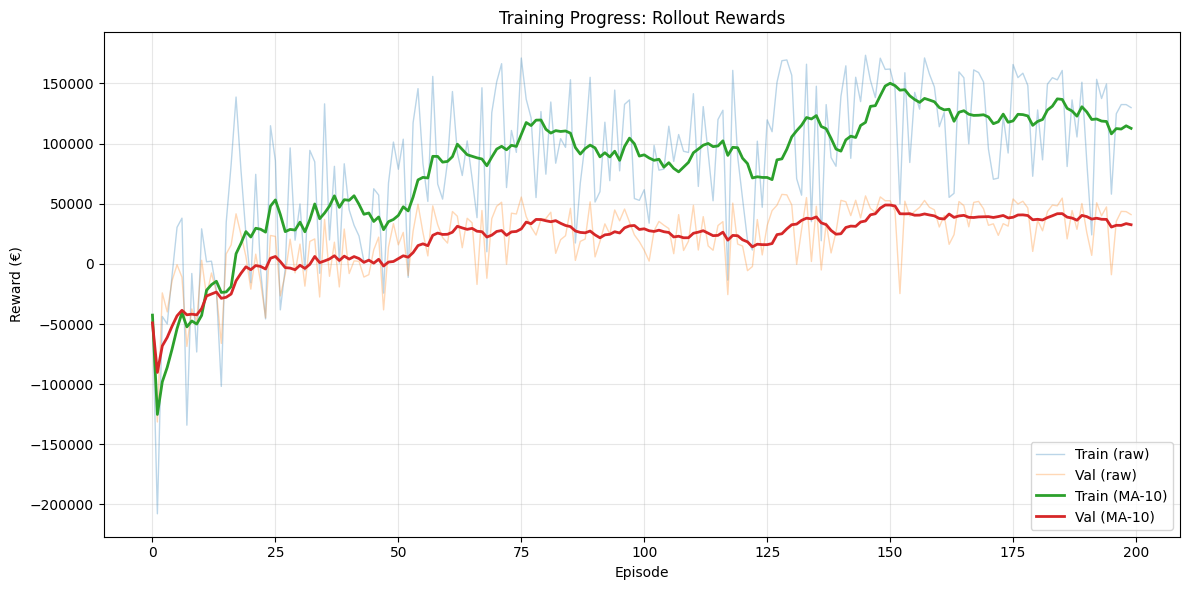

In [41]:
plt.figure(figsize=(12, 6))

# Plot raw data (lighter, thinner)
plt.plot(metrics.episode, metrics.train_rollout, alpha=0.3, linewidth=1, label='Train (raw)')
plt.plot(metrics.episode, metrics.val_rollout, alpha=0.3, linewidth=1, label='Val (raw)')

# Plot moving averages (darker, thicker)
window = 10
train_ma = metrics.train_rollout.rolling(window=window, min_periods=1).mean()
val_ma = metrics.val_rollout.rolling(window=window, min_periods=1).mean()

plt.plot(metrics.episode, train_ma, linewidth=2, label=f'Train (MA-{window})')
plt.plot(metrics.episode, val_ma, linewidth=2, label=f'Val (MA-{window})')

plt.xlabel('Episode')
plt.ylabel('Reward (€)')
plt.title('Training Progress: Rollout Rewards')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [44]:
metrics.columns

Index(['episode', 'epsilon', 'lr', 'raw_reward', 'q_reward', 'train_rollout',
       'val_rollout', 'q_delta', 'q_mean', 'n_table_pct_non_zero',
       'n_table_min', 'n_table_max', 'n_table_mean', 'n_table_median'],
      dtype='object')

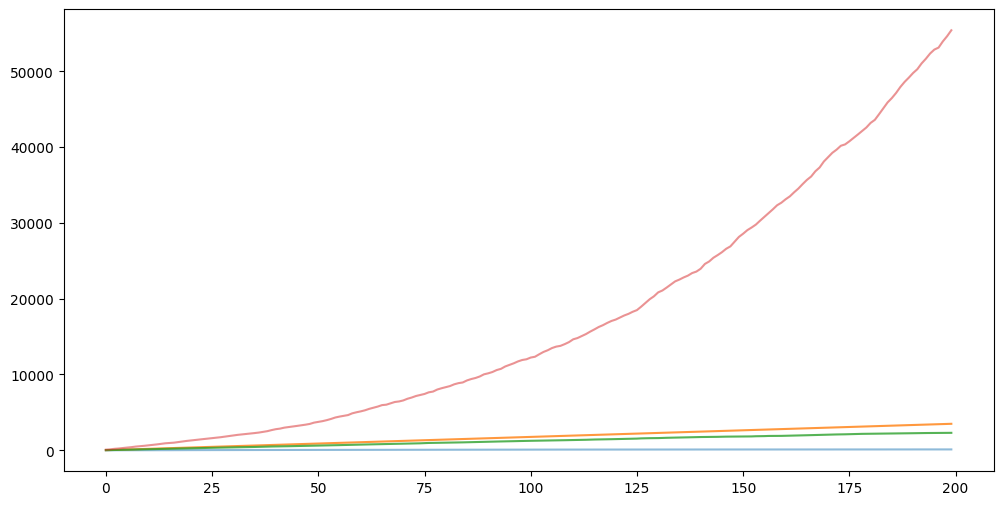

In [48]:
plt.figure(figsize=(12, 6))

plt.plot(metrics.episode, metrics.n_table_min, alpha=0.5, label='Min N-table')
plt.plot(metrics.episode, metrics.n_table_mean, alpha=0.8, label='Mean N-table')
plt.plot(metrics.episode, metrics.n_table_median, alpha=0.8, label='Median N-table')
plt.plot(metrics.episode, metrics.n_table_max, alpha=0.5, label='Max N-table')

<Axes: >

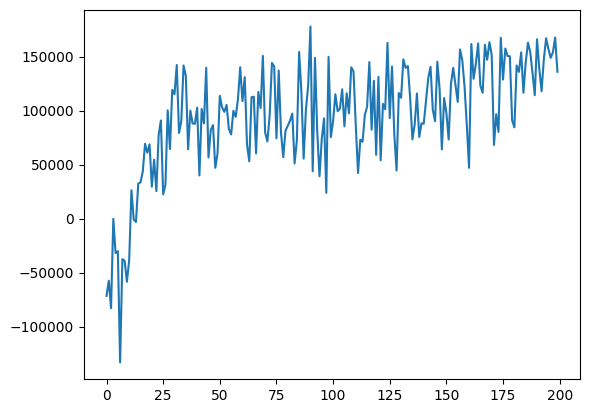

In [25]:
metrics.train_rollout.plot()
